In [1]:
import mlflow
import os
import socket

# FORCE MLflow to local mode immediately to stop connection errors
for var in ['MLFLOW_TRACKING_URI', 'http_proxy', 'https_proxy', 'HTTP_PROXY', 'HTTPS_PROXY']:
    os.environ.pop(var, None)

mlflow.set_tracking_uri('sqlite:///mlflow.db')
print(f'CRITICAL: MLflow is now FORCED to local mode: {mlflow.get_tracking_uri()}')


CRITICAL: MLflow is now FORCED to local mode: sqlite:///mlflow.db


# Assignment 2: Cats vs Dogs Classification Pipeline

This notebook covers the complete end-to-end MLOps pipeline for image classification, including data generation, EDA, training, and experiment tracking with MLflow.

## 1. Import Required Libraries and Configuration
Setting up the environment and tracking parameters.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import mlflow
import mlflow.pytorch
import os
import sys
import requests
import socket
import numpy as np
import matplotlib.pyplot as plt
import warnings
from PIL import Image
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Suppress MLflow warning about artifact_path deprecation
warnings.filterwarnings("ignore", message=".*artifact_path is deprecated.*")

# Configuration
DATA_DIR = 'data'
MODEL_DIR = 'models'
TRACKING_URI = "http://127.0.0.1:5000"
EXPERIMENT_NAME = "Cats_vs_Dogs_Classification_Notebook"

os.makedirs(MODEL_DIR, exist_ok=True)

def setup_mlflow():
    # Clear any environment variables that might interfere
    for var in ['MLFLOW_TRACKING_URI', 'http_proxy', 'https_proxy', 'HTTP_PROXY', 'HTTPS_PROXY']:
        os.environ.pop(var, None)
    
    # Robust MLflow Connection Check using low-level socket
    is_reachable = False
    try:
        host = "127.0.0.1"
        port = 5000
        with socket.create_connection((host, port), timeout=1):
            is_reachable = True
    except:
        is_reachable = False

    if is_reachable:
        mlflow.set_tracking_uri(TRACKING_URI)
        print(f"Successfully connected to MLflow server at: {TRACKING_URI}")
    else:
        local_uri = "sqlite:///mlflow.db"
        mlflow.set_tracking_uri(local_uri)
        print(f"MLflow server at {TRACKING_URI} is unreachable. Falling back to: {mlflow.get_tracking_uri()}")

setup_mlflow()

MLflow server at http://127.0.0.1:5000 is unreachable. Falling back to: sqlite:///mlflow.db


## 2. Data Acquisition and Cleaning
Generating synthetic data for the assignment flow.

In [4]:
def generate_synthetic_data(data_dir, num_samples=100):
    os.makedirs(os.path.join(data_dir, 'train', 'cats'), exist_ok=True)
    os.makedirs(os.path.join(data_dir, 'train', 'dogs'), exist_ok=True)
    os.makedirs(os.path.join(data_dir, 'val', 'cats'), exist_ok=True)
    os.makedirs(os.path.join(data_dir, 'val', 'dogs'), exist_ok=True)

    for split in ['train', 'val']:
        for label in ['cats', 'dogs']:
            for i in range(num_samples // 4):
                img_array = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
                if label == 'cats':
                    img_array[:50, :50, 0] = 255 # Red pattern for cats
                else:
                    img_array[:50, :50, 2] = 255 # Blue pattern for dogs
                
                img = Image.fromarray(img_array)
                img.save(os.path.join(data_dir, split, label, f"{label}_{i}.jpg"))

generate_synthetic_data(DATA_DIR)
print("Synthetic data generated successfully.")

Synthetic data generated successfully.


## 3. EDA (Exploratory Data Analysis)
Visualizing the generated dataset.

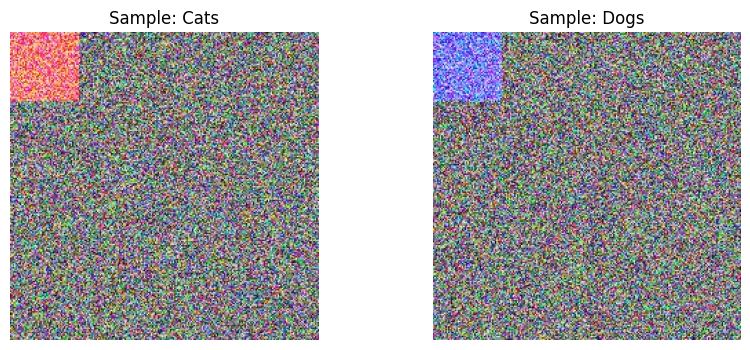

In [6]:
def plot_samples(target_dir):
    classes = ['cats', 'dogs']
    plt.figure(figsize=(10, 4))
    for i, cls in enumerate(classes):
        img_path = os.path.join(target_dir, 'train', cls, f"{cls}_0.jpg")
        img = Image.open(img_path)
        plt.subplot(1, 2, i+1)
        plt.imshow(img)
        plt.title(f"Sample: {cls.capitalize()}")
        plt.axis('off')
    plt.show()

plot_samples(DATA_DIR)

## 4. Feature Engineering & Preprocessing
Defining image transformations and loaders.

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"DataLoaders created. Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

DataLoaders created. Training samples: 20050, Validation samples: 5048


## 5. Model Development & Experiment Tracking
Defining the CNN architecture and training with MLflow logging.

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 56 * 56)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def run_training(epochs=1, lr=0.001):
    # Ensure MLflow is correctly configured before starting
    setup_mlflow()
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    mlflow.set_experiment(EXPERIMENT_NAME)

    with mlflow.start_run():
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("lr", lr)
        mlflow.log_param("batch_size", 16)
        
        losses = []

        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
            
            avg_loss = running_loss/len(train_loader)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss}")
            mlflow.log_metric("train_loss", avg_loss, step=epoch)
            losses.append(avg_loss)

        # Generation of Loss Curve Artifact
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, epochs + 1), losses, marker='o')
        plt.title('Training Loss Curve')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True)
        os.makedirs('artifacts', exist_ok=True)
        plt.savefig('artifacts/loss_curve_notebook.png')
        plt.close()
        mlflow.log_artifact('artifacts/loss_curve_notebook.png')

        # Evaluation & Advanced Metrics Logging
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        accuracy = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds)
        recall = recall_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds)

        print(f"Validation Metrics - Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1: {f1}")
        mlflow.log_metrics({
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1
        })

        # Generation of Confusion Matrix Artifact
        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cat', 'Dog'])
        plt.figure(figsize=(8, 6))
        disp.plot(cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.savefig('artifacts/confusion_matrix_notebook.png')
        plt.close()
        mlflow.log_artifact('artifacts/confusion_matrix_notebook.png')

        # Save and Log Models (Weights & Packaging)
        save_path = os.path.join(MODEL_DIR, 'model_notebook.pt')
        torch.save(model.state_dict(), save_path)
        mlflow.pytorch.log_model(
            pytorch_model=model, 
            artifact_path="model",
            pip_requirements=[
                "torch==2.2.0",
                "torchvision==0.17.0",
                "mlflow"
            ]
        )
        mlflow.log_artifact(save_path, artifact_path="weights")
        print(f"Model saved locally to {save_path} and logged to MLflow weights/")

run_training(epochs=1)

MLflow server at http://127.0.0.1:5000 is unreachable. Falling back to: sqlite:///mlflow.db


2026/02/20 13:04:34 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/20 13:04:34 INFO mlflow.store.db.utils: Updating database tables
2026/02/20 13:04:34 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/20 13:04:34 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/02/20 13:04:35 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/20 13:04:35 INFO alembic.runtime.migration: Will assume non-transactional DDL.


Epoch 1/1, Loss: 0.6049257246762562


c:\Users\jmajjigi\AppData\Local\miniconda3\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Validation Metrics - Accuracy: 0.7301901743264659, Precision: 0.6981582537517054, Recall: 0.811014263074485, F1: 0.750366568914956


2026/02/20 13:35:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Model saved locally to models\model_notebook.pt and logged to MLflow weights/


<Figure size 800x600 with 0 Axes>

## 6. Model Packaging & Reproducibility
Explaining how the tracked experiment ensures reproducibility.

By using `mlflow.pytorch.log_model`, we have packaged the model with its dependencies. 
You can now:
1. View the run in the MLflow UI.
2. Download the `conda.yaml` or `requirements.txt` generated by MLflow for this specific run.
3. Serve the model using `mlflow models serve`.